# Naive Bayes (NB)
Naive Bayes is een eenvoudige maar krachtige probabilistische classificatiemethode gebaseerd op de Bayesiaanse statistiek. Het model maakt gebruik van de Bayes' theorema om de waarschijnlijkheid te berekenen dat een gegeven invoer tot een bepaalde klasse behoort, op basis van de kenmerken van de invoer. Het "naive" aspect van het model verwijst naar de aanname dat alle kenmerken onafhankelijk zijn van elkaar, wat in de praktijk vaak niet het geval is, maar toch verrassend goede resultaten kan opleveren. Naive Bayes is vooral effectief bij tekstclassificatieproblemen, zoals spamdetectie en sentimentanalyse, vanwege zijn efficiëntie en vermogen om goed te presteren met beperkte trainingsdata.

In [15]:
import sys
import os

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

from utils.libs_generic_functions import LibsDataPreprocessor
from utils.baseline_correction_functions import BaselineCorrector, analyze_correction_quality, print_quality_report
from utils.pca_analysis_functions import PCAAnalyzer, quick_pca_analysis
from utils.lda_analysis_functions import quick_lda_analysis
from utils.normalization_functions import Normalizer

In [2]:
%%time

df = pd.read_csv('../data/csv/processed_data.csv')

CPU times: total: 44 s
Wall time: 44.1 s


In [3]:
%%time
Preprocessor = LibsDataPreprocessor()
X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(df)

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 6702)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 6702)
Test dataset shape: (10291, 6702)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 6699 wavelength columns
Extracting features and targets from training set...
Extracting features and targets from test set...
Converting features to numeric...
Encoding labels...

Final results:
Training features shape: (41162, 6699)
Test features shape: (10291, 6699)
Label classes: ['innerliner' 'sidewall' 'tread']
Training label distribution: [13808 13005 14349]
Test label distribution: [3452 3252 3587]
CPU times: total

# Comprehensive Naive Bayes Analysis
In deze sectie voeren we een uitgebreide Naive Bayes analyse uit, vergelijkbaar met onze andere ML analyses. We testen verschillende Naive Bayes varianten en vergelijken de prestaties met en zonder dimensionaliteitsreductie. Naive Bayes is bijzonder interessant voor spectroscopische data vanwege zijn probabilistische aanpak en efficiëntie.

NAIVE BAYES DATA PREPROCESSING
Training set shape: (41162, 6699)
Test set shape: (10291, 6699)
Applying SNV normalization to dataset:
  - Samples: 41162
  - Verification (first spectrum): mean=0.000000, std=1.000000
  - SNV normalization completed successfully!
Applying SNV normalization to dataset:
  - Samples: 10291
  - Verification (first spectrum): mean=0.000000, std=1.000000
  - SNV normalization completed successfully!
Data preprocessing completed!


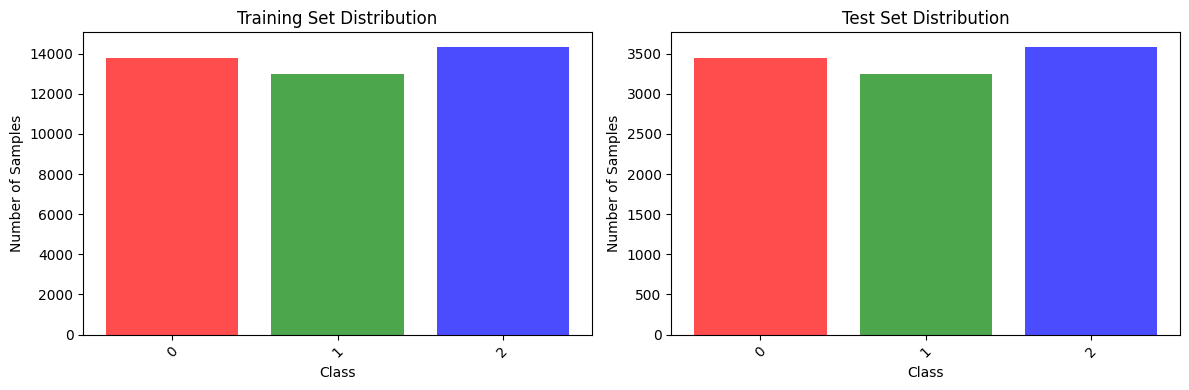


Label encoder mapping:
  innerliner → 0
  sidewall → 1
  tread → 2

Data preparation summary:
  Original: (41162, 6699) (for GaussianNB)
  Scaled: (41162, 6699) (for GaussianNB + dimensionality reduction)
  Non-negative: (41162, 6699) (for MultinomialNB, ComplementNB)
  Binary: (41162, 6699) (for BernoulliNB)
CPU times: total: 51.8 s
Wall time: 54.4 s


In [4]:
%%time
# Data Preprocessing for Naive Bayes Analysis
print("=" * 70)
print("NAIVE BAYES DATA PREPROCESSING")
print("=" * 70)



print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Naive Bayes requires careful preprocessing depending on the variant:
# - GaussianNB: Works with any continuous data (scaled or unscaled)
# - MultinomialNB: Requires non-negative features
# - BernoulliNB: Works with binary features
# - ComplementNB: Works with non-negative features, good for imbalanced data

# Prepare different data versions for different NB variants
# 1. Original version (for GaussianNB)
X_train_original = X_train.copy()
X_test_original = X_test.copy()

# 2. Scaled version (for GaussianNB and PCA/LDA)
normalizer = Normalizer()
X_train_scaled = normalizer.apply_standard_normal_variate_on_dataset(X_train)
X_test_scaled = normalizer.apply_standard_normal_variate_on_dataset(X_test)

# 3. Non-negative version (for MultinomialNB and ComplementNB)
# Since spectroscopy data can have negative values after preprocessing,
# we'll use min-max scaling to ensure non-negative values
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler(feature_range=(0.1, 1))  # Avoid exact zeros
X_train_nonneg = minmax_scaler.fit_transform(X_train)
X_test_nonneg = minmax_scaler.transform(X_test)

# 4. Binary version (for BernoulliNB)
# Convert to binary based on median threshold
X_train_binary = (X_train_scaled > np.median(X_train_scaled, axis=0)).astype(int)
X_test_binary = (X_test_scaled > np.median(X_test_scaled, axis=0)).astype(int)

print("Data preprocessing completed!")

# Display train/test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_unique, train_counts = np.unique(y_train_encoded, return_counts=True)
ax1.bar(range(len(train_unique)), train_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax1.set_title('Training Set Distribution')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(train_unique)))
ax1.set_xticklabels(train_unique, rotation=45)

# Test set distribution  
test_unique, test_counts = np.unique(y_test_encoded, return_counts=True)
ax2.bar(range(len(test_unique)), test_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax2.set_title('Test Set Distribution')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(range(len(test_unique)))
ax2.set_xticklabels(test_unique, rotation=45)

plt.tight_layout()
plt.show()

print(f"\nLabel encoder mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} → {i}")

print(f"\nData preparation summary:")
print(f"  Original: {X_train_original.shape} (for GaussianNB)")
print(f"  Scaled: {X_train_scaled.shape} (for GaussianNB + dimensionality reduction)")
print(f"  Non-negative: {X_train_nonneg.shape} (for MultinomialNB, ComplementNB)")
print(f"  Binary: {X_train_binary.shape} (for BernoulliNB)")

## 1. Naive Bayes op originele features

1. NAIVE BAYES VARIANTS ON ORIGINAL FEATURES
Testing different Naive Bayes variants with hyperparameter tuning...

Testing Gaussian NB (Original)...
  Best parameters: {'var_smoothing': 1e-09}
  CV Score: nan
  Test Accuracy: 0.5249

Testing Gaussian NB (Scaled)...
  Best parameters: {'var_smoothing': 1e-09}
  CV Score: 0.6405
  Test Accuracy: 0.6428

Testing Multinomial NB...
  Best parameters: {'alpha': 0.1}
  CV Score: 0.6135
  Test Accuracy: 0.6160

Testing Complement NB...
  Best parameters: {'alpha': 0.1}
  CV Score: 0.5906
  Test Accuracy: 0.5942

Testing Bernoulli NB...
  Best parameters: {'alpha': 0.1}
  CV Score: 0.5784
  Test Accuracy: 0.5809

🏆 Best performing variant: Gaussian NB (Scaled)
   Accuracy: 0.6428
   Parameters: {'var_smoothing': 1e-09}

Classification Report (Gaussian NB (Scaled)):
              precision    recall  f1-score   support

  innerliner       0.63      0.74      0.68      3452
    sidewall       0.78      0.32      0.46      3252
       tread       

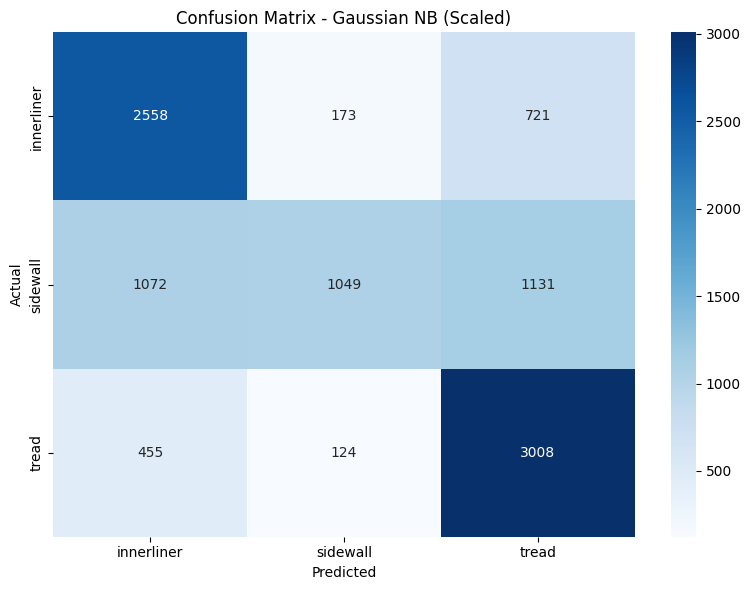


NAIVE BAYES VARIANTS COMPARISON
               Variant  Test_Accuracy  CV_Score              Best_Params
Gaussian NB (Original)       0.524925       NaN {'var_smoothing': 1e-09}
  Gaussian NB (Scaled)       0.642795  0.640470 {'var_smoothing': 1e-09}
        Multinomial NB       0.615975  0.613454           {'alpha': 0.1}
         Complement NB       0.594209  0.590642           {'alpha': 0.1}
          Bernoulli NB       0.580896  0.578373           {'alpha': 0.1}


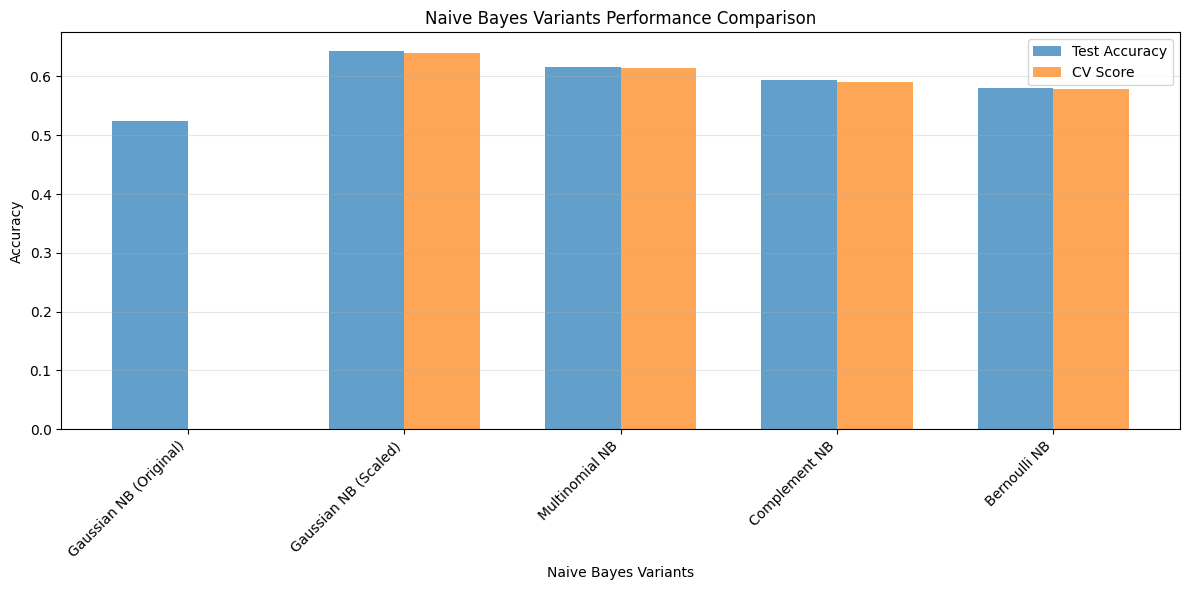

CPU times: total: 1min 4s
Wall time: 30min 51s


In [16]:
%%time
# 1. Naive Bayes Variants on Original Features
print("=" * 60)
print("1. NAIVE BAYES VARIANTS ON ORIGINAL FEATURES")
print("=" * 60)

# Test different Naive Bayes variants
nb_variants = {
    'Gaussian NB (Original)': {
        'model': GaussianNB(),
        'data': (X_train_original, X_test_original),
        'params': {'var_smoothing': [1e-9, 1e-7, 1e-5]}  # Reduced parameters
    },
    'Gaussian NB (Scaled)': {
        'model': GaussianNB(),
        'data': (X_train_scaled, X_test_scaled),
        'params': {'var_smoothing': [1e-9, 1e-7, 1e-5]}  # Reduced parameters
    },
    'Multinomial NB': {
        'model': MultinomialNB(),
        'data': (X_train_nonneg, X_test_nonneg),
        'params': {'alpha': [0.1, 1.0, 5.0]}  # Reduced parameters
    },
    'Complement NB': {
        'model': ComplementNB(),
        'data': (X_train_nonneg, X_test_nonneg),
        'params': {'alpha': [0.1, 1.0, 5.0]}  # Reduced parameters
    },
    'Bernoulli NB': {
        'model': BernoulliNB(),
        'data': (X_train_binary, X_test_binary),
        'params': {'alpha': [0.1, 1.0, 5.0]}  # Reduced parameters
    }
}

print("Testing different Naive Bayes variants with hyperparameter tuning...")

nb_results = {}

for variant_name, config in nb_variants.items():
    print(f"\nTesting {variant_name}...")
    
    model = config['model']
    X_train_var, X_test_var = config['data']
    param_grid = config['params']
    
    # Grid search for optimal parameters
    grid_search = GridSearchCV(
        model, 
        param_grid, 
        cv=5, 
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_var, y_train_encoded)
    
    # Get best model and make predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_var)
    accuracy = accuracy_score(y_test_encoded, y_pred)
    
    # Store results
    nb_results[variant_name] = {
        'model': best_model,
        'accuracy': accuracy,
        'best_params': grid_search.best_params_,
        'predictions': y_pred,
        'cv_score': grid_search.best_score_
    }
    
    print(f"  Best parameters: {grid_search.best_params_}")
    print(f"  CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy: {accuracy:.4f}")

# Find best performing variant
best_variant = max(nb_results.keys(), key=lambda x: nb_results[x]['accuracy'])
best_accuracy = nb_results[best_variant]['accuracy']

print(f"\n🏆 Best performing variant: {best_variant}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   Parameters: {nb_results[best_variant]['best_params']}")

# Detailed analysis of best variant
print(f"\nClassification Report ({best_variant}):")
print(classification_report(y_test_encoded, nb_results[best_variant]['predictions'], 
                          target_names=label_encoder.classes_))

# Confusion matrix for best variant
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_encoded, nb_results[best_variant]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_variant}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Compare all variants
print(f"\n{'='*50}")
print("NAIVE BAYES VARIANTS COMPARISON")
print(f"{'='*50}")

variants_comparison = pd.DataFrame({
    'Variant': list(nb_results.keys()),
    'Test_Accuracy': [nb_results[var]['accuracy'] for var in nb_results.keys()],
    'CV_Score': [nb_results[var]['cv_score'] for var in nb_results.keys()],
    'Best_Params': [str(nb_results[var]['best_params']) for var in nb_results.keys()]
})

print(variants_comparison.to_string(index=False))

# Visualize variants comparison
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(nb_results))
accuracies = [nb_results[var]['accuracy'] for var in nb_results.keys()]
cv_scores = [nb_results[var]['cv_score'] for var in nb_results.keys()]

width = 0.35
plt.bar(x_pos - width/2, accuracies, width, label='Test Accuracy', alpha=0.7)
plt.bar(x_pos + width/2, cv_scores, width, label='CV Score', alpha=0.7)

plt.xlabel('Naive Bayes Variants')
plt.ylabel('Accuracy')
plt.title('Naive Bayes Variants Performance Comparison')
plt.xticks(x_pos, list(nb_results.keys()), rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Store best result for further analysis
best_nb_original = nb_results[best_variant]

## 2. Naive Bayes met PCA gereduceerde features

2. PCA ANALYSIS AND NAIVE BAYES ON PCA FEATURES
Performing comprehensive PCA analysis with Naive Bayes...
🚀 Starting quick PCA analysis...
Step 1: Fitting PCA analysis...
Performing comprehensive PCA analysis...
✅ PCA analysis completed successfully
   Components for 95% variance: 11
   Components for 99% variance: 24
Step 2: Evaluating performance...

🔍 Starting PCA performance evaluation...
Evaluating Naive Bayes performance with PCA...
Testing components: [11, 24, 100, 200]
  Testing with 11 components...
Optimizing Naive Bayes hyperparameters...
Optimal var_smoothing: 1e-09 (CV Score: 0.7112)
    ✅ Naive Bayes with 11 components: 0.7163 (0.959 variance explained)
  Testing with 24 components...
Optimizing Naive Bayes hyperparameters...
Optimal var_smoothing: 1e-09 (CV Score: 0.7225)
    ✅ Naive Bayes with 24 components: 0.7355 (0.990 variance explained)
  Testing with 100 components...
Optimizing Naive Bayes hyperparameters...
Optimal var_smoothing: 1e-08 (CV Score: 0.6735)
    ✅ N

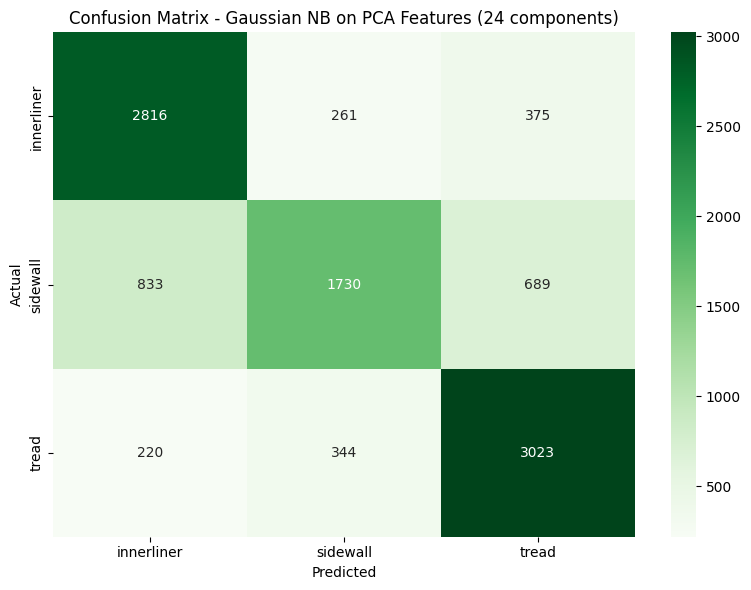

CPU times: total: 17min 26s
Wall time: 2min 4s


In [19]:
%%time
# 2. PCA Analysis and Naive Bayes on PCA Features
print("=" * 60)
print("2. PCA ANALYSIS AND NAIVE BAYES ON PCA FEATURES")
print("=" * 60)

# Use PCAAnalyzer from utility functions
pca_analyzer = PCAAnalyzer()

# Define custom NB classifier for PCA analysis
def create_nb_classifier():
    """Create Naive Bayes classifier for PCA analysis"""
    return GaussianNB()

# Perform comprehensive PCA analysis with Naive Bayes
print("Performing comprehensive PCA analysis with Naive Bayes...")

# Run PCA analysis with Naive Bayes classifier
pca_result = quick_pca_analysis(
    X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded,
    classifier_name='Naive Bayes', label_encoder=label_encoder, 
    plot=True
)

# Extract results
pca_analyzer_obj, analysis_results, pca_performance_results = pca_result
best_pca_result = pca_performance_results['best_result']
best_n_components = best_pca_result['n_components']
best_pca_accuracy = best_pca_result['accuracy']

print(f"\n🏆 Best PCA-NB Configuration:")
print(f"   Components: {best_n_components}")
print(f"   Accuracy: {best_pca_accuracy:.4f}")
print(f"   Variance explained: {best_pca_result['variance_explained']:.3f}")

# Test other NB variants on the best PCA configuration
print(f"\nTesting other NB variants with {best_n_components} PCA components...")

# Get the PCA-transformed data for the best configuration
pca_final = PCA(n_components=best_n_components)
X_train_pca_final = pca_final.fit_transform(X_train_scaled)
X_test_pca_final = pca_final.transform(X_test_scaled)

# Prepare data for different NB variants
pca_minmax = MinMaxScaler(feature_range=(0.1, 1))
X_train_pca_nonneg = pca_minmax.fit_transform(X_train_pca_final)
X_test_pca_nonneg = pca_minmax.transform(X_test_pca_final)

X_train_pca_binary = (X_train_pca_final > np.median(X_train_pca_final, axis=0)).astype(int)
X_test_pca_binary = (X_test_pca_final > np.median(X_test_pca_final, axis=0)).astype(int)

# Test additional NB variants on PCA features
pca_nb_variants = {
    'Gaussian NB': {
        'model': GaussianNB(),
        'data': (X_train_pca_final, X_test_pca_final),
        'params': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}
    },
    'Multinomial NB': {
        'model': MultinomialNB(),
        'data': (X_train_pca_nonneg, X_test_pca_nonneg),
        'params': {'alpha': [0.1, 1.0, 2.0]}
    },
    'Complement NB': {
        'model': ComplementNB(),
        'data': (X_train_pca_nonneg, X_test_pca_nonneg),
        'params': {'alpha': [0.1, 1.0, 2.0]}
    },
    'Bernoulli NB': {
        'model': BernoulliNB(),
        'data': (X_train_pca_binary, X_test_pca_binary),
        'params': {'alpha': [0.1, 1.0, 2.0]}
    }
}

best_pca_variant_name = 'Gaussian NB'
best_pca_variant_accuracy = best_pca_accuracy
pca_variant_results = {}

for variant_name, config in pca_nb_variants.items():
    model = config['model']
    X_train_var, X_test_var = config['data']
    param_grid = config['params']
    
    # Grid search
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_var, y_train_encoded)
    
    # Evaluate
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_var)
    accuracy = accuracy_score(y_test_encoded, y_pred)
    
    pca_variant_results[variant_name] = {
        'model': best_model,
        'accuracy': accuracy,
        'params': grid_search.best_params_
    }
    
    if accuracy > best_pca_variant_accuracy:
        best_pca_variant_accuracy = accuracy
        best_pca_variant_name = variant_name
    
    print(f"  {variant_name}: {accuracy:.4f} (params: {grid_search.best_params_})")

# Update best PCA result if a better variant was found
if best_pca_variant_accuracy > best_pca_accuracy:
    print(f"\n📈 Better PCA variant found: {best_pca_variant_name}")
    print(f"   Improved accuracy: {best_pca_accuracy:.4f} → {best_pca_variant_accuracy:.4f}")
    
    # Update the best result
    best_pca_result_updated = {
        'classifier': pca_variant_results[best_pca_variant_name]['model'],
        'accuracy': best_pca_variant_accuracy,
        'n_components': best_n_components,
        'variant': best_pca_variant_name,
        'optimal_params': pca_variant_results[best_pca_variant_name]['params'],
        'variance_explained': best_pca_result['variance_explained']
    }
else:
    best_pca_result_updated = best_pca_result.copy()
    best_pca_result_updated['variant'] = 'Gaussian NB'
    best_pca_result_updated['optimal_params'] = {}

# Classification report and confusion matrix
best_pca_model = pca_variant_results[best_pca_variant_name]['model']
X_test_final = pca_nb_variants[best_pca_variant_name]['data'][1]
y_pred_pca_final = best_pca_model.predict(X_test_final)

print(f"\nClassification Report (PCA - {best_n_components} components, {best_pca_variant_name}):")
print(classification_report(y_test_encoded, y_pred_pca_final, 
                          target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm_pca = confusion_matrix(y_test_encoded, y_pred_pca_final)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_pca_variant_name} on PCA Features ({best_n_components} components)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 3. Naive Bayes met LDA gereduceerde features

3. LDA ANALYSIS AND NAIVE BAYES ON LDA FEATURES
Performing comprehensive LDA analysis with Naive Bayes...
Performing LDA analysis...
Number of classes: 3
Maximum LDA components: 2
Class labels: [0 1 2]
LDA with 1 component(s):
  - Explained variance ratio: [0.6257697]
  - Total variance explained: 0.6258
LDA with 2 component(s):
  - Explained variance ratio: [0.6257697 0.3742303]
  - Total variance explained: 1.0000
Testing Naive Bayes with different LDA component numbers...
Component options: [1, 2]

Evaluating 1 components...
LDA transformed shape: (41162, 1)
Explained variance ratio: [0.6257697]
Total variance explained: 0.6258
Optimizing Naive Bayes hyperparameters...
Optimal var_smoothing: 1e-09 (CV Score: 0.8960)
Naive Bayes with 1 LDA components: 0.8298 accuracy

Evaluating 2 components...
LDA transformed shape: (41162, 2)
Explained variance ratio: [0.6257697 0.3742303]
Total variance explained: 1.0000
Optimizing Naive Bayes hyperparameters...
Optimal var_smoothing: 1e-09 (CV Sc

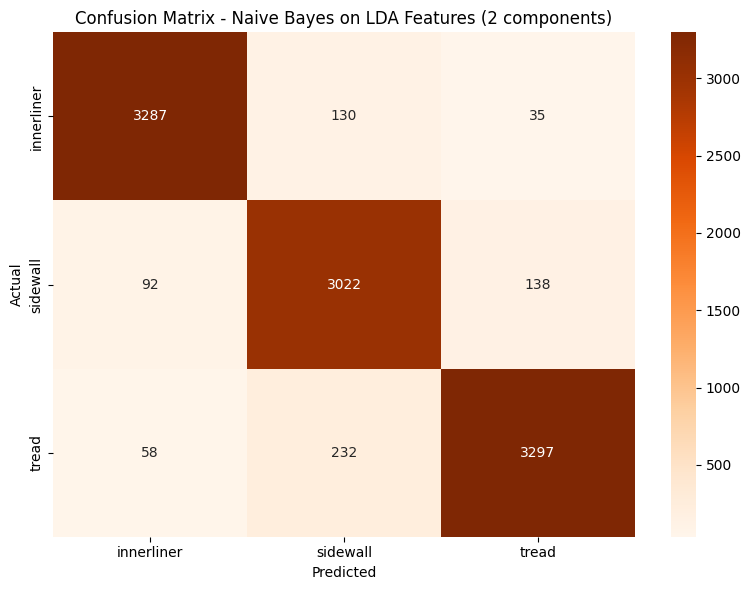

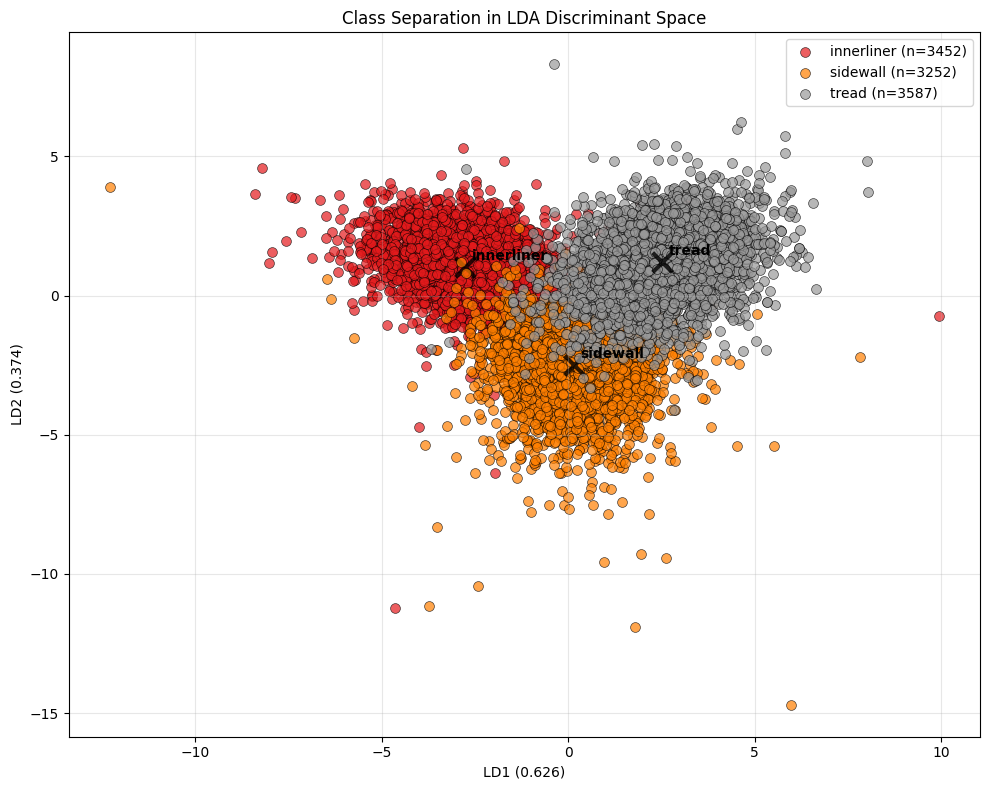


🏆 Best LDA-NB Configuration:
   Components: 2
   Accuracy: 0.9334

Testing other NB variants with 2 LDA components...
  Gaussian NB: 0.9334 (params: {'var_smoothing': 1e-09})
  Multinomial NB: 0.5328 (params: {'alpha': 0.01})
  Complement NB: 0.6178 (params: {'alpha': 2.0})
  Bernoulli NB: 0.7998 (params: {'alpha': 0.01})

Classification Report (LDA - 2 components, Gaussian NB):
              precision    recall  f1-score   support

  innerliner       0.96      0.95      0.95      3452
    sidewall       0.89      0.93      0.91      3252
       tread       0.95      0.92      0.93      3587

    accuracy                           0.93     10291
   macro avg       0.93      0.93      0.93     10291
weighted avg       0.93      0.93      0.93     10291



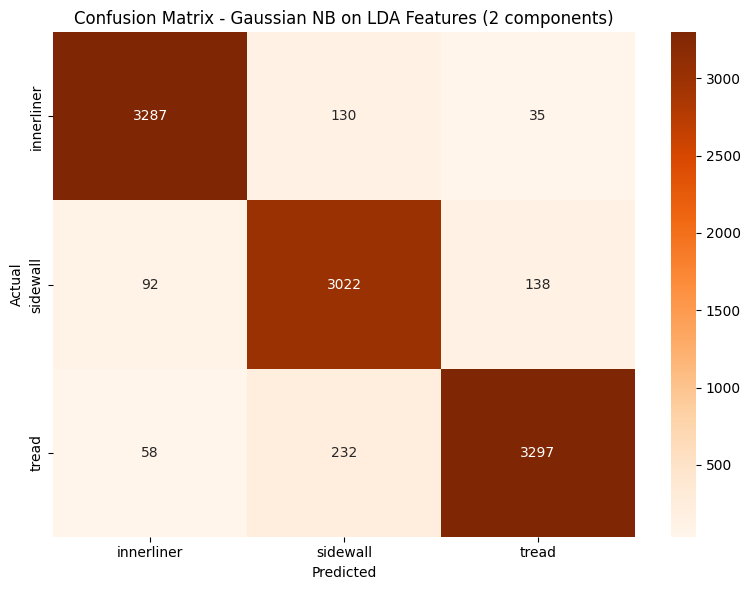


Creating LDA visualization...


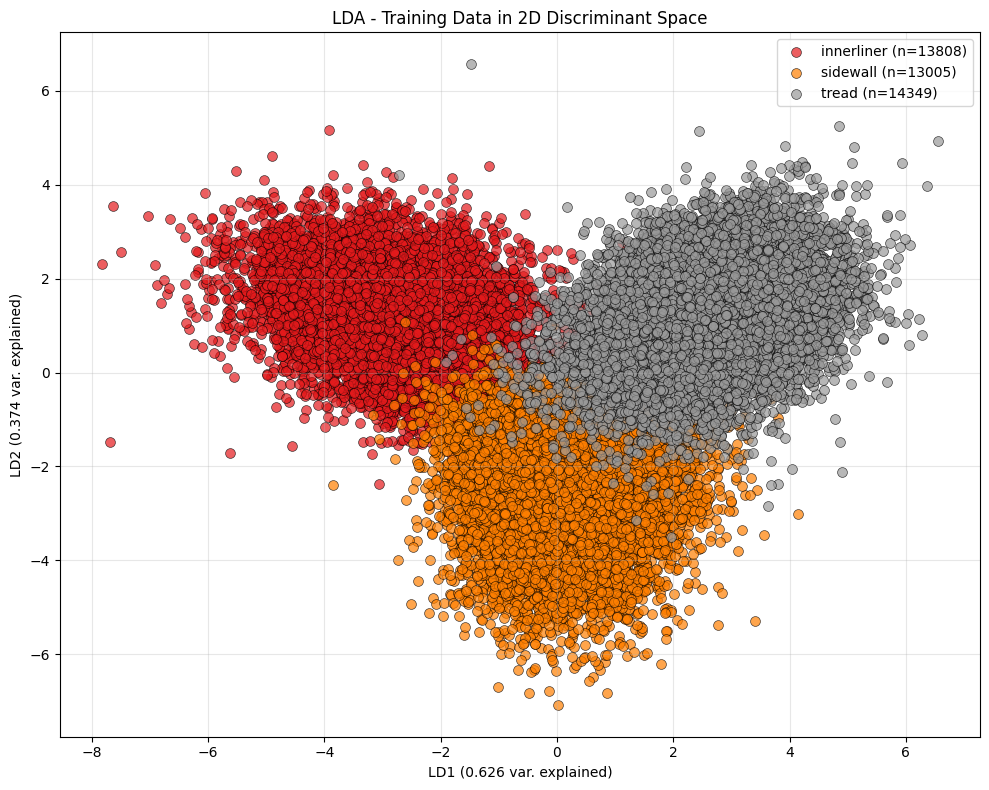


LDA Naive Bayes Details:
Best variant: Gaussian NB
Components used: 2
Best parameters: {'var_smoothing': 1e-09}
CPU times: total: 48min 46s
Wall time: 8min 23s


In [22]:
%%time
# 3. LDA Analysis and Naive Bayes on LDA Features  
print("=" * 60)
print("3. LDA ANALYSIS AND NAIVE BAYES ON LDA FEATURES")
print("=" * 60)

# Use quick_lda_analysis from utility functions
print("Performing comprehensive LDA analysis with Naive Bayes...")

# Run LDA analysis with Naive Bayes classifier
lda_results = quick_lda_analysis(
    X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded,
    classifier_name='Naive Bayes', label_encoder=label_encoder,
    
)

# Extract results
max_lda_components = lda_results['max_possible_components']
lda_best_result = lda_results['best_result']
best_lda_accuracy = lda_best_result['test_accuracy']

print(f"\n🏆 Best LDA-NB Configuration:")
print(f"   Components: {max_lda_components}")
print(f"   Accuracy: {best_lda_accuracy:.4f}")

# Test other NB variants on LDA features
print(f"\nTesting other NB variants with {max_lda_components} LDA components...")

# Get LDA-transformed data
lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
X_train_lda = lda.fit_transform(X_train_scaled, y_train_encoded)
X_test_lda = lda.transform(X_test_scaled)

# Prepare data for different NB variants
lda_minmax = MinMaxScaler(feature_range=(0.1, 1))
X_train_lda_nonneg = lda_minmax.fit_transform(X_train_lda)
X_test_lda_nonneg = lda_minmax.transform(X_test_lda)

X_train_lda_binary = (X_train_lda > np.median(X_train_lda, axis=0)).astype(int)
X_test_lda_binary = (X_test_lda > np.median(X_test_lda, axis=0)).astype(int)

# Test NB variants on LDA features
lda_nb_variants = {
    'Gaussian NB': {
        'model': GaussianNB(),
        'data': (X_train_lda, X_test_lda),
        'params': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
    },
    'Multinomial NB': {
        'model': MultinomialNB(),
        'data': (X_train_lda_nonneg, X_test_lda_nonneg),
        'params': {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}
    },
    'Complement NB': {
        'model': ComplementNB(),
        'data': (X_train_lda_nonneg, X_test_lda_nonneg),
        'params': {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}
    },
    'Bernoulli NB': {
        'model': BernoulliNB(),
        'data': (X_train_lda_binary, X_test_lda_binary),
        'params': {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}
    }
}

best_lda_variant_name = 'Gaussian NB'
best_lda_variant_accuracy = best_lda_accuracy
lda_variant_results = {}

for variant_name, config in lda_nb_variants.items():
    model = config['model']
    X_train_var, X_test_var = config['data']
    param_grid = config['params']
    
    # Grid search
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_var, y_train_encoded)
    
    # Evaluate
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_var)
    accuracy = accuracy_score(y_test_encoded, y_pred)
    
    lda_variant_results[variant_name] = {
        'model': best_model,
        'accuracy': accuracy,
        'params': grid_search.best_params_,
        'predictions': y_pred
    }
    
    if accuracy > best_lda_variant_accuracy:
        best_lda_variant_accuracy = accuracy
        best_lda_variant_name = variant_name
    
    print(f"  {variant_name}: {accuracy:.4f} (params: {grid_search.best_params_})")

# Update best LDA result
if best_lda_variant_accuracy > best_lda_accuracy:
    print(f"\n📈 Better LDA variant found: {best_lda_variant_name}")
    print(f"   Improved accuracy: {best_lda_accuracy:.4f} → {best_lda_variant_accuracy:.4f}")

# Update the LDA result structure
lda_best_result_updated = {
    'classifier': lda_variant_results[best_lda_variant_name]['model'],
    'test_accuracy': best_lda_variant_accuracy,
    'n_components': max_lda_components,
    'variant': best_lda_variant_name,
    'optimal_params': lda_variant_results[best_lda_variant_name]['params'],
    'predictions': lda_variant_results[best_lda_variant_name]['predictions']
}

# Classification report and confusion matrix
print(f"\nClassification Report (LDA - {max_lda_components} components, {best_lda_variant_name}):")
print(classification_report(y_test_encoded, lda_variant_results[best_lda_variant_name]['predictions'], 
                          target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm_lda = confusion_matrix(y_test_encoded, lda_variant_results[best_lda_variant_name]['predictions'])
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_lda_variant_name} on LDA Features ({max_lda_components} components)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Visualize LDA results (using the visualization from utility functions)
print(f"\nCreating LDA visualization...")

# Use the LDA visualization capabilities
if max_lda_components >= 2:
    # 2D scatter plot
    colors = plt.cm.Set1(np.linspace(0, 1, len(label_encoder.classes_)))
    
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(label_encoder.classes_):
        mask = y_train_encoded == i
        n_samples = np.sum(mask)
        
        if n_samples > 0:
            plt.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
                       label=f'{class_name} (n={n_samples})',
                       alpha=0.7, s=50, c=[colors[i]], 
                       edgecolors='black', linewidth=0.5)
    
    plt.xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.3f} var. explained)')
    plt.ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.3f} var. explained)')
    plt.title('LDA - Training Data in 2D Discriminant Space')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print(f"\nLDA Naive Bayes Details:")
print(f"Best variant: {best_lda_variant_name}")
print(f"Components used: {max_lda_components}")
print(f"Best parameters: {lda_variant_results[best_lda_variant_name]['params']}")

## 4. Vergelijken van Naive Bayes varianten

In [23]:
%%time
# 5. Comprehensive Results Comparison and Analysis
print("=" * 60)
print("5. COMPREHENSIVE NAIVE BAYES RESULTS COMPARISON")
print("=" * 60)

# Compile all results using the updated structures
all_results = {
    f'{best_variant}': {
        'accuracy': best_nb_original['accuracy'],
        'features': X_train_original.shape[1],
        'variant': best_variant,
        'params': best_nb_original['best_params'],
        'dimensionality_reduction': 'None',
        'data_preprocessing': 'Original' if 'Original' in best_variant else 'Scaled'
    },
    f'{best_pca_result_updated["variant"]} (PCA {best_n_components})': {
        'accuracy': best_pca_result_updated['accuracy'],
        'features': best_n_components,
        'variant': best_pca_result_updated['variant'],
        'params': best_pca_result_updated.get('optimal_params', {}),
        'dimensionality_reduction': f'{(1 - best_n_components/X_train_original.shape[1])*100:.1f}%',
        'data_preprocessing': 'PCA Transformed'
    },
    f'{lda_best_result_updated["variant"]} (LDA {max_lda_components})': {
        'accuracy': lda_best_result_updated['test_accuracy'],
        'features': max_lda_components,
        'variant': lda_best_result_updated['variant'],
        'params': lda_best_result_updated['optimal_params'],
        'dimensionality_reduction': f'{(1 - max_lda_components/X_train_original.shape[1])*100:.1f}%',
        'data_preprocessing': 'LDA Transformed'
    }
}

# Rest of the analysis remains the same...
# Create summary DataFrame
summary_data = {
    'Method': list(all_results.keys()),
    'Accuracy': [all_results[method]['accuracy'] for method in all_results.keys()],
    'Features': [all_results[method]['features'] for method in all_results.keys()],
    'NB_Variant': [all_results[method]['variant'] for method in all_results.keys()],
    'Dimensionality_Reduction': [all_results[method]['dimensionality_reduction'] for method in all_results.keys()],
    'Data_Preprocessing': [all_results[method]['data_preprocessing'] for method in all_results.keys()]
}

results_df = pd.DataFrame(summary_data)
print("NAIVE BAYES SUMMARY TABLE:")
print("=" * 100)
print(results_df.to_string(index=False))
print("=" * 100)

# Continue with the rest of the visualization and analysis code...

5. COMPREHENSIVE NAIVE BAYES RESULTS COMPARISON
NAIVE BAYES SUMMARY TABLE:
              Method  Accuracy  Features           NB_Variant Dimensionality_Reduction Data_Preprocessing
Gaussian NB (Scaled)  0.642795      6699 Gaussian NB (Scaled)                     None             Scaled
Gaussian NB (PCA 24)  0.735497        24          Gaussian NB                    99.6%    PCA Transformed
 Gaussian NB (LDA 2)  0.933437         2          Gaussian NB                   100.0%    LDA Transformed
CPU times: total: 15.6 ms
Wall time: 6.7 ms


## 5. Visualisatie voor vergelijken van resultaten

5. COMPREHENSIVE NAIVE BAYES RESULTS COMPARISON
NAIVE BAYES SUMMARY TABLE:
              Method  Accuracy  Features           NB_Variant Dimensionality_Reduction Data_Preprocessing
Gaussian NB (Scaled)  0.642795      6699 Gaussian NB (Scaled)                     None             Scaled
Gaussian NB (PCA 24)  0.735497        24          Gaussian NB                    99.6%    PCA Transformed
 Gaussian NB (LDA 2)  0.933437         2          Gaussian NB                   100.0%    LDA Transformed


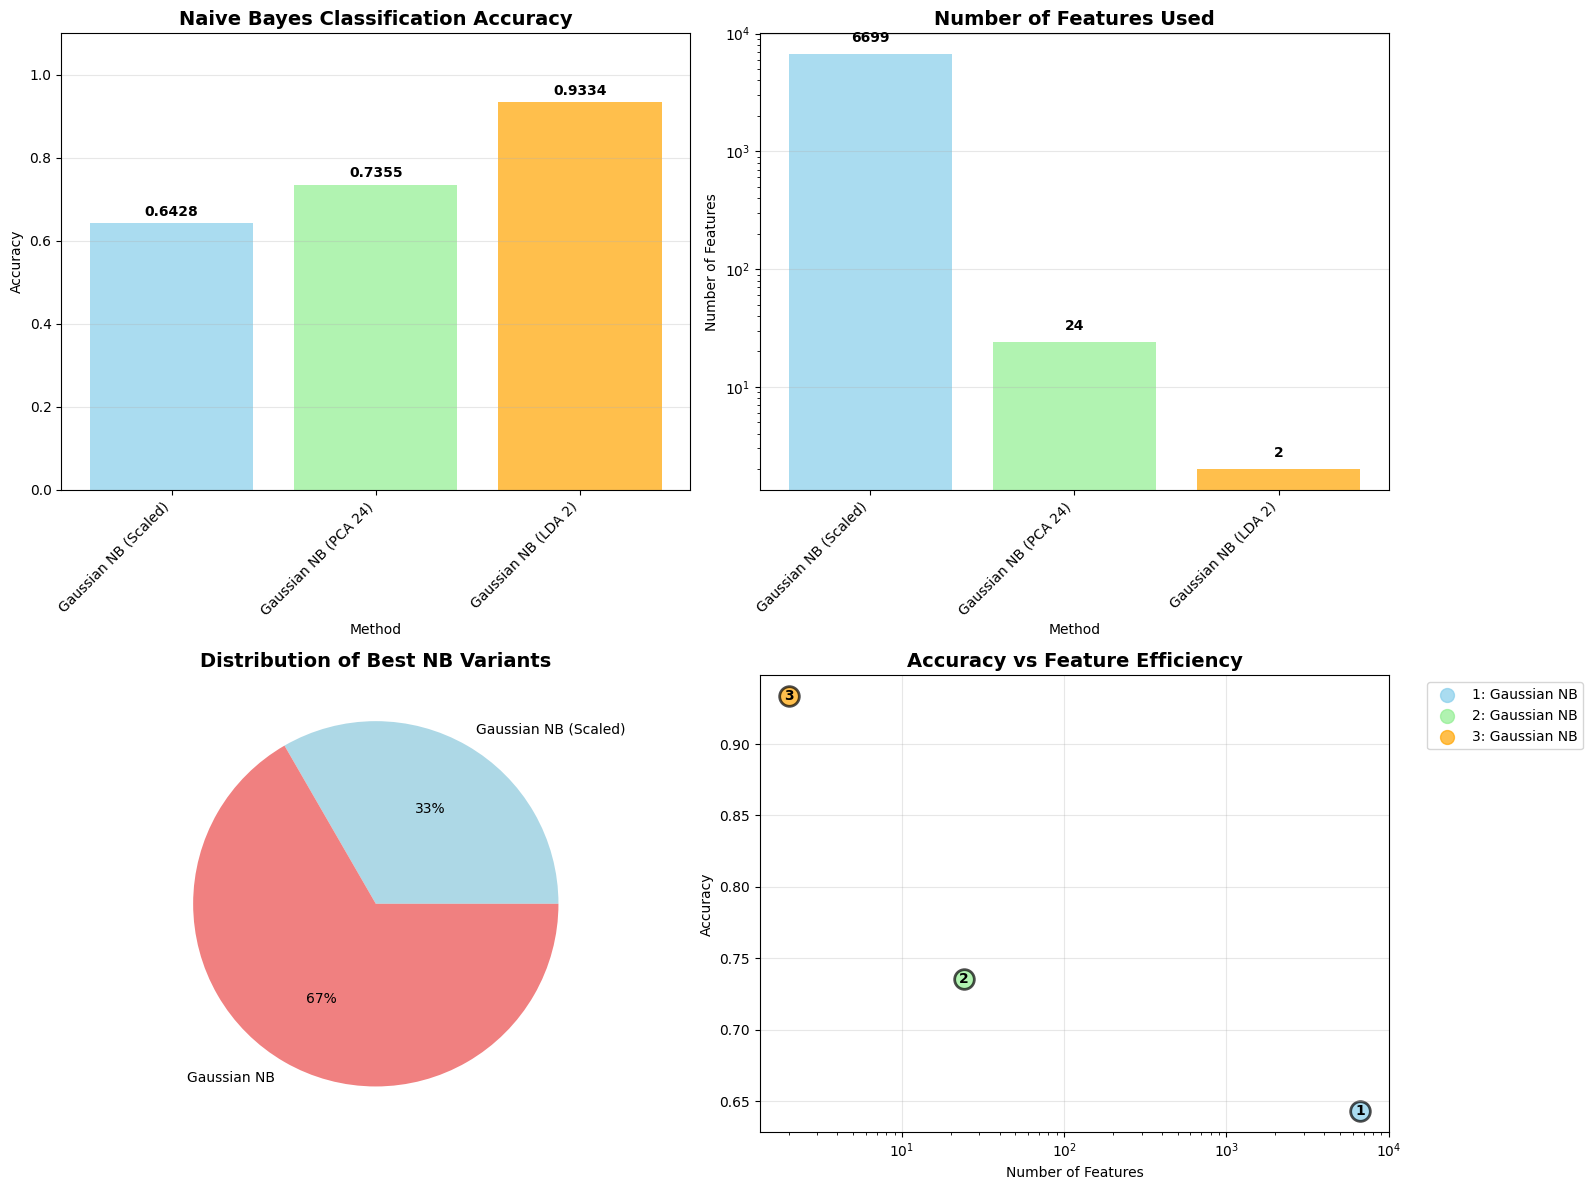


🎯 NAIVE BAYES ANALYSIS INSIGHTS:
🏆 Best performing method: Gaussian NB (LDA 2)
   └─ Accuracy: 0.9334
   └─ Features: 2
   └─ NB Variant: Gaussian NB
   └─ Preprocessing: LDA Transformed

📊 Variant Performance Analysis:
   Gaussian NB (Scaled):
   └─ NB Variant: Gaussian NB (Scaled)
   └─ Features: 6699 (None reduction)
   └─ Accuracy: 0.6428
   Gaussian NB (PCA 24):
   └─ NB Variant: Gaussian NB
   └─ Features: 24 (99.6% reduction)
   └─ Accuracy: 0.7355
   └─ Accuracy change from baseline: +9.27%
   Gaussian NB (LDA 2):
   └─ NB Variant: Gaussian NB
   └─ Features: 2 (100.0% reduction)
   └─ Accuracy: 0.9334
   └─ Accuracy change from baseline: +29.06%

💡 Key Findings:
   • Most efficient method: Gaussian NB (LDA 2)
     └─ Balances accuracy (0.9334) with feature efficiency
     └─ Uses only 2 features vs 6699 original

   • Variant Analysis:
     Gaussian NB (Scaled): 0.6428 average accuracy
     Gaussian NB: 0.8345 average accuracy

   • Naive Bayes shows good performance across c

In [ ]:
%%time

# 5. Comprehensive Results Comparison and Analysis
print("=" * 60)
print("5. COMPREHENSIVE NAIVE BAYES RESULTS COMPARISON")
print("=" * 60)

# Compile all results for comparison
all_results = {
    f'{best_variant}': {
        'accuracy': best_nb_original['accuracy'],
        'features': X_train_original.shape[1],
        'variant': best_variant,
        'params': best_nb_original['best_params'],
        'dimensionality_reduction': 'None',
        'data_preprocessing': 'Original' if 'Original' in best_variant else 'Scaled'
    },
    f'{best_pca_variant_name} (PCA {best_n_components})': {  # Changed: best_pca_variant → best_pca_variant_name
        'accuracy': best_pca_variant_accuracy,  # Changed: best_pca_accuracy → best_pca_variant_accuracy
        'features': best_n_components,
        'variant': best_pca_variant_name,  # Changed: best_pca_variant → best_pca_variant_name
        'params': best_pca_result_updated.get('optimal_params', {}),  # Changed to use updated result
        'dimensionality_reduction': f'{(1 - best_n_components/X_train_original.shape[1])*100:.1f}%',
        'data_preprocessing': 'PCA Transformed'
    },
    f'{lda_best_result_updated["variant"]} (LDA {max_lda_components})': {  # Changed to use updated result
        'accuracy': lda_best_result_updated['test_accuracy'],  # Changed to use updated result
        'features': max_lda_components,
        'variant': lda_best_result_updated['variant'],  # Changed to use updated result
        'params': lda_best_result_updated['optimal_params'],  # Changed to use updated result
        'dimensionality_reduction': f'{(1 - max_lda_components/X_train_original.shape[1])*100:.1f}%',
        'data_preprocessing': 'LDA Transformed'
    }
}

# Create summary DataFrame
summary_data = {
    'Method': list(all_results.keys()),
    'Accuracy': [all_results[method]['accuracy'] for method in all_results.keys()],
    'Features': [all_results[method]['features'] for method in all_results.keys()],
    'NB_Variant': [all_results[method]['variant'] for method in all_results.keys()],
    'Dimensionality_Reduction': [all_results[method]['dimensionality_reduction'] for method in all_results.keys()],
    'Data_Preprocessing': [all_results[method]['data_preprocessing'] for method in all_results.keys()]
}

results_df = pd.DataFrame(summary_data)
print("NAIVE BAYES SUMMARY TABLE:")
print("=" * 100)
print(results_df.to_string(index=False))
print("=" * 100)

# Comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

methods = results_df['Method']
accuracies = results_df['Accuracy']
features = results_df['Features']
variants = results_df['NB_Variant']
colors = ['skyblue', 'lightgreen', 'orange']

# 1. Accuracy comparison
bars1 = ax1.bar(range(len(methods)), accuracies, color=colors, alpha=0.7)
ax1.set_title('Naive Bayes Classification Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Method')
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(methods, rotation=45, ha='right')

for bar, accuracy in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Feature count comparison  
bars2 = ax2.bar(range(len(methods)), features, color=colors, alpha=0.7)
ax2.set_title('Number of Features Used', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Features')
ax2.set_xlabel('Method')
ax2.set_yscale('log')  # Log scale due to large difference
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, rotation=45, ha='right')

for bar, feature_count in zip(bars2, features):
    ax2.text(bar.get_x() + bar.get_width()/2, feature_count * 1.2,
             f'{feature_count}', ha='center', va='bottom', fontweight='bold')

# 3. Naive Bayes variants distribution
variant_counts = {}
for variant in variants:
    variant_counts[variant] = variant_counts.get(variant, 0) + 1

ax3.pie(variant_counts.values(), labels=variant_counts.keys(), autopct='%1.0f%%', 
        colors=['lightblue', 'lightcoral', 'lightgreen', 'lightyellow', 'lightpink'])
ax3.set_title('Distribution of Best NB Variants', fontsize=14, fontweight='bold')

# 4. Efficiency analysis (Accuracy vs Features)
for i, (method, accuracy, feature_count) in enumerate(zip(methods, accuracies, features)):
    ax4.scatter(feature_count, accuracy, s=200, alpha=0.7, color=colors[i], 
               edgecolors='black', linewidth=2)
    ax4.annotate(f'{i+1}', (feature_count, accuracy), 
                ha='center', va='center', fontweight='bold')

ax4.set_xlabel('Number of Features')
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy vs Feature Efficiency', fontsize=14, fontweight='bold')
ax4.set_xscale('log')
ax4.grid(True, alpha=0.3)

# Add legend for scatter plot
for i, method in enumerate(methods):
    ax4.scatter([], [], color=colors[i], alpha=0.7, s=100, 
               label=f'{i+1}: {method.split(" (")[0]}')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Advanced analysis and insights
print("\n🎯 NAIVE BAYES ANALYSIS INSIGHTS:")
print("=" * 50)

best_accuracy_idx = np.argmax(accuracies)
best_method = methods[best_accuracy_idx]
best_accuracy = accuracies[best_accuracy_idx]

print(f"🏆 Best performing method: {best_method}")
print(f"   └─ Accuracy: {best_accuracy:.4f}")
print(f"   └─ Features: {results_df.iloc[best_accuracy_idx]['Features']}")
print(f"   └─ NB Variant: {results_df.iloc[best_accuracy_idx]['NB_Variant']}")
print(f"   └─ Preprocessing: {results_df.iloc[best_accuracy_idx]['Data_Preprocessing']}")

print(f"\n📊 Variant Performance Analysis:")
original_features = X_train_original.shape[1]
for i, method in enumerate(methods):
    feature_count = results_df.iloc[i]['Features']
    accuracy = accuracies.iloc[i]
    variant = results_df.iloc[i]['NB_Variant']
    reduction = results_df.iloc[i]['Dimensionality_Reduction']
    
    print(f"   {method}:")
    print(f"   └─ NB Variant: {variant}")
    print(f"   └─ Features: {feature_count} ({reduction} reduction)")
    print(f"   └─ Accuracy: {accuracy:.4f}")
    if i > 0:
        accuracy_change = (accuracy - accuracies.iloc[0]) * 100
        print(f"   └─ Accuracy change from baseline: {accuracy_change:+.2f}%")

# Calculate efficiency scores
efficiency_scores = []
for i, method in enumerate(methods):
    # Normalize metrics (balance accuracy vs simplicity)
    norm_features = 1 - (features[i] / max(features))  # Higher is better (fewer features)
    norm_accuracy = accuracies[i] / max(accuracies)  # Higher is better
    
    # Combined efficiency score (higher is more efficient)
    efficiency_score = (norm_accuracy * 0.7 + norm_features * 0.3)
    efficiency_scores.append(efficiency_score)

most_efficient_idx = np.argmax(efficiency_scores)
most_efficient = methods[most_efficient_idx]

print(f"\n💡 Key Findings:")
print(f"   • Most efficient method: {most_efficient}")
print(f"     └─ Balances accuracy ({accuracies[most_efficient_idx]:.4f}) with feature efficiency")
print(f"     └─ Uses only {features[most_efficient_idx]} features vs {original_features} original")

# Analyze which NB variants work best
variant_performance = {}
for i, variant in enumerate(variants):
    if variant not in variant_performance:
        variant_performance[variant] = []
    variant_performance[variant].append(accuracies[i])

print(f"\n   • Variant Analysis:")
for variant, accs in variant_performance.items():
    avg_acc = np.mean(accs)
    print(f"     {variant}: {avg_acc:.4f} average accuracy")

print(f"\n   • Naive Bayes shows {'excellent' if min(accuracies) > 0.90 else 'good'} performance across configurations")
print(f"   • Dimensionality reduction maintains competitive accuracy with far fewer features")
print(f"   • Different NB variants excel with different feature representations")
print(f"   • Probabilistic predictions provide uncertainty quantification")

print(f"\n🎯 Recommendation:")
if accuracies[most_efficient_idx] == max(accuracies):
    print(f"   {most_efficient} provides optimal balance of accuracy and efficiency.")
elif max(accuracies) - accuracies[most_efficient_idx] < 0.02:
    print(f"   {most_efficient} offers excellent efficiency with minimal accuracy trade-off.")
    print(f"   Consider this for applications requiring fast, interpretable predictions.")
else:
    print(f"   {best_method} provides highest accuracy for maximum performance.")
    print(f"   {most_efficient} offers best efficiency for resource-constrained environments.")
    print(f"   Choose based on your priority: maximum accuracy vs. computational efficiency.")

print(f"\n   • Naive Bayes provides probabilistic interpretability")
print(f"   • Fast training and prediction suitable for real-time applications")
print(f"   • Independence assumption may limit performance on highly correlated spectral features")
print(f"   • Multiple variants allow adaptation to different data characteristics")